# Синтаксис 

Синтаксическую разметку продуктивнее всего получать с помощью библиотек stanza или spacy. Сегодня попробуем разобраться с spacy.

## Spacy

In [ ]:
#!pip install spacy

In [ ]:
import spacy

In [ ]:
import pandas as pd
import requests

Будем использовать маленькую модель для скорости, однако для серьёзной работы всегда используйте большие модели для более высокого качества разметки. Список моделей можно найти здесь: https://spacy.io/models

Для установки разных моделей нужно написать следующий код в командной строке:
1. python -m spacy download ru_core_news_sm - малая модель для русского
2. python -m spacy download ru_core_news_lg - большая модель для русского
3. python -m spacy download en_core_web_sm - малая для английского
4. python -m spacy download pl_core_news_sm - малая для польского

In [ ]:
#!python -m spacy download ru_core_news_sm 

In [ ]:
#!python -m spacy download pl_core_news_sm 

In [ ]:
#!python -m spacy download en_core_web_sm 

Подругим модель:

In [ ]:
nlp_ru = spacy.load("ru_core_news_sm")

Сама разметка spacy ещё проще, чем в stanza:

In [ ]:
text = 'Компания Газпром любит красивых кошек.' 

In [ ]:
doc = nlp_ru(text)

for token in doc:
    print(token.text, token.lemma_, token.pos_, token.tag_, token.dep_,
            token.shape_, token.is_alpha, token.is_stop)


Можно достаточно просто достать морфологию:

In [ ]:
token = doc[4]
print(token.text)
print(token.lemma_)
print(token.morph)  

И зная конкретные пожелания по грамматическому признаку, можно извлечь только его:

In [ ]:
print(token.morph.get("Gender"))  

## Перейдём к синтаксису

Список возможных тэгов, указывающих на тип зависимости здесь: https://universaldependencies.org/u/dep/

In [ ]:
text = 'Apetyt rośnie w miarę jedzenia'
nlp_pol = spacy.load("pl_core_news_sm")

Разбор из тьюториала:

In [ ]:
doc = nlp_pol(text)
for token in doc:
    print(token.text, token.dep_, token.head.text, token.head.pos_, 
            [child for child in token.children])

Закинем в табличку для удобочитаемости:

In [ ]:
texts = [token.text for token in doc]
deps = [token.dep_ for token in doc]
heads = [token.head.text for token in doc]
heads_pos = [token.head.pos_ for token in doc]
children_t = [[child for child in token.children] for token in doc]


print(children_t)

In [ ]:
df = pd.DataFrame({'token': texts, 
                   'deprel': deps,
                   'head': heads,
                   'head_pos': heads_pos,
                   'children': children_t
                    })

df

Столбец **head** обозначает, какое слово является вершиной конкретного слова. Например, в предложении выше алгоритм считает, что вершиной предложения является "rośnie" (ROOT), а его непосредственными зависимыми являются Apetyt и jedzenia.

Можно обходить дерево и находить кандидатов по определённым условиям. Например, будем находить сказуемые в предложении:

In [ ]:
verbs = []
for possible_subject in doc:
   # print(possible_subject.dep_)
    if possible_subject.dep_ == 'nsubj':
        print(f'Ура! {possible_subject.text} - это, наверное, подлежащее!') 
        #теперь осталось найти глагольную вершину подлежащего - это и есть сказуемое
    if possible_subject.dep_ == 'nsubj' and possible_subject.head.pos_ == 'VERB':
        verbs.append(possible_subject.head) #
print(verbs)


Возьмём текст побольше (стихотворение Яна Бжехвы) и посмотрим на результат:

In [ ]:
samochwala = '''
Samochwała w kącie stała
I wciąż tak opowiadała:
"Zdolna jestem niesłychanie,
Najpiękniejsze mam ubranie,
Moja buzia tryska zdrowiem,
Jak coś powiem, to już powiem,
Jak odpowiem, to roztropnie,
W szkole mam najlepsze stopnie,
Śpiewam lepiej niż w operze,
Świetnie jeżdżę na rowerze,
Znakomicie muchy łapię,
Wiem, gdzie Wisła jest na mapie,
Jestem mądra, jestem zgrabna,
Wiotka, słodka i powabna,
A w dodatku, daję słowo,
Mam rodzinę wyjątkową:
Tato mój do pieca sięga,
Moja mama - taka tęga
Moja siostra - taka mała,
A ja jestem - samochwała!"
'''
samochwala_doc = nlp_pol(samochwala)
samochwala_texts = [token.text for token in samochwala_doc]
samochwala_deps = [token.dep_ for token in samochwala_doc]
samochwala_heads = [token.head.text for token in samochwala_doc]
samochwala_heads_pos = [token.head.pos_ for token in samochwala_doc]
samochwala_children_t = [[child for child in token.children] for token in samochwala_doc]

samochwala_df = pd.DataFrame({'token': samochwala_texts, 
                   'deprel': samochwala_deps,
                   'head': samochwala_heads,
                   'head_pos': samochwala_heads_pos,
                   'children': samochwala_children_t
                    })

samochwala_df

In [ ]:
verbs = []
for possible_subject in samochwala_doc:
   # print(possible_subject.dep_)
    if possible_subject.dep_ == 'nsubj':
        print(f'Ура! {possible_subject.text} - это, наверное, подлежащее!') 
        #теперь осталось найти глагольную вершину подлежащего - это и есть сказуемое
    if possible_subject.dep_ == 'nsubj' and possible_subject.head.pos_ == 'VERB':
        print(f'Ура! {possible_subject.head.pos_} - это, наверное, сказуемое!') 
        verbs.append(possible_subject.head) #
print(verbs)


In [ ]:
text_pin = '''
 Wszedł na plac Sienny. Było mu nieprzyjemnie, bardzo nieprzyjemnie spotykać się z ludźmi, ale szedł właśnie tam, gdzie tłum był największy. Dałby był wszystko na świecie, ażeby zostać samemu; ale sam czuł że ani chwili nie będzie sam. W tłumie dokazywał jakiś pijak, chciał tańczyć, lecz ciągle zataczał się w rynsztok. Obstąpiono go. Raskolnikow przecisnął się przez tłum, przez kilka minut patrzył na pijanego, i nagle zaśmiał się krótko i urywanie. Po chwili zapomniał już o nim, nawet go nie widział, lubo i patrzył nań. Odszedł nareszcie, nie pamiętając nawet, gdzie się znajduje; ale gdy doszedł do środka placu, zadrżał nagle, jakieś uczucie owładnęło nim raptownie, ogarnęło go nawskroś — z ciałem i myślą.
 Przyszły mu nagle na myśl słowa Zosi: „Idź na rozdroże, pokłoń się ludziom, ucałuj ziemię, boś zgrzeszył i względem niej, i powiedz głośno: „jestem zabójcą!“ Zadrżał cały, przypomniawszy to sobie. I już do tego stopnia zgnębiła go trwoga, utrapienie tych ostatnich czasów, a zwłaszcza ostatnich godzin, że aż uczepił się możliwości tego całkowicie nowego, zupełnego wrażenia. Zbyt jakoś natrętnie przypadło doń ono: zapłonęło w duszy jedną iskierką i nagle jak ogień objęło go całego. Wszystko w nim nagle rozmiękło i łzy bryznęły. Jak stał, tak i upadł na ziemię...
 Ukląkł na środku placu, pokłonił się do ziemi i pocałował ten błotnisty bruk z rozkoszą i szczęściem. Wstał i pokłonił się po raz drugi...
 — A to się schlał! — zauważył obok niego jakiś wyrostek.
 Dał się słyszeć śmiech.
 — On, widzicie, do Jerozolimy idzie; z dziećmi, z ojczyzną się żegna, kłania się całemu światu, stołeczne miasto Sanktpetersburg i jego grunt obcałowuje — dodał jakiś pijaniusienki mieszczanin.
 — Chłopak jeszcze młody! — wtrącił trzeci.
 — Z porządnych — zauważył ktoś poważnym głosem.
 — Dzisiaj trudno rozpoznać, kto porządny, a kto nie.
 Wszystkie te głosy i rozmowy powstrzymywały Raskolnikowa i słowa: „jam zabił“, które miał już w pogotowiu, zamarły mu na ustach. Atoli spokojnie zniósł te wszystkie krzyki i nie oglądając się, poszedł prosto przez zaułek w kierunku biura cyrkułowego. Jakieś widmo błysnęło mu w drodze przed oczyma, ale nie zadziwiło go wcale: przeczuwał już, że tak być powinno. W czasie, gdy na placu Siennym pokłonił się powtórnie ku ziemi, odwróciwszy się na lewo, o jakie pięćdziesiąt kroków, spostrzegł Zosię. Chowała się przed nim za jednę z drewnianych budek, a więc towarzyszyła mu w czasie całego tego smutnego pochodu! Raskolnikow uczuł i zrozumiał w tej chwili, raz na zawsze, że Zosia teraz z nim będzie na wieki i pójdzie za nim choćby na koniec świata, gdziekolwiek go losy rzucą. Serce w nim zadrgało... ale, otóż i doszedł do fatalnego kresu...
 Dosyć raźno wszedł na podwórze. Trzeba było wejść na trzecie piętro.
 Zanim jeszcze dojdę — pomyślał.
 Wogóle zdawało mu się, że do chwili stanowczej jeszcze daleko, jeszcze dużo czasu zostaje, wiele rzeczy można jeszcze obmyśleć.
 Znowu te same śmieci, te same skorupy na kręconych schodach, znowu drzwi od mieszkań otwarte naoścież znowu te same kuchnie, z których dolatuje czad i smród. Raskolnikow od tamtego czasu nie był tu jeszcze. Nogi odmawiały mu posłuszeństwa, uginały się pod nim, ale szły. Stanął na chwilę dla nabrania powietrza, ażeby zawładnąć sobą i wejść jak człowiek.
'''

Можем сделать функцию, чтобы не копировать большие куски кода:

In [ ]:
def synt_table_polish(txt, dep, head):
    doc_f = nlp_pol(txt)
    f_doc = nlp_pol(samochwala)
    f_texts = [token.text for token in doc_f]
    f_deps = [token.dep_ for token in doc_f]
    f_heads = [token.head.text for token in doc_f]
    f_heads_pos = [token.head.pos_ for token in doc_f]
    f_children_t = [[child for child in token.children] for token in doc_f]

    df_f = pd.DataFrame({'token': f_texts, 
                   'deprel': f_deps,
                   'head': f_heads,
                   'head_pos': f_heads_pos,
                   'children': f_children_t
                    })


    targs = []
    for possible_subject in doc_f:
       if possible_subject.dep_ == str(dep) and possible_subject.head.pos_ == str(head):
            targs.append(possible_subject.head) 

    
    return df_f, targs

In [ ]:
result_pin = synt_table_polish(text_pin, 'nsubj', 'VERB')

In [ ]:
result_pin[0]

In [ ]:
result_pin[1]

Помимо этого можно смотреть на правое и левое ветвление синтаксического дерева.

In [ ]:
doc = nlp_ru("Прекрасный летний день резвился всеми цветами, доступными суровой северной погоде.")
print([token.text for token in doc[3].lefts]) #cмотрим на элемент 3, т.е. глагол "резвился"
print([token.text for token in doc[3].rights])  

In [ ]:
print([token.text for token in doc[7].lefts]) #cмотрим на элемент 3, т.е. на "доступными"
print([token.text for token in doc[7].rights])  

Можно достать всю фразу целиком по вершине:

In [ ]:
root = [token for token in doc if token.head == token][0] #достанем вершину всего предложения
#print(root)
subject = list(root.lefts)[0] #достанем подлежащее, часто это первое левое зависимое
#print(subject)
for descendant in subject.subtree: #в subtree лежат все зависимые полученного выше subject
    assert subject is descendant or subject.is_ancestor(descendant) #проверяем, что каждое слово в subtree либо само является subject, либо является его потомком
    print(descendant.text, descendant.dep_, #информация о зависимом
            [ancestor.text for ancestor in descendant.ancestors]) #информация о группе, от которой зависит конкретное слово

Также в spacy есть готовый инструмент для отрисовки синтаксических деревьев:

In [ ]:
from spacy import displacy

In [ ]:
displacy.render(doc, style="dep")

In [ ]:
displacy.render(doc, style="dep", options={
        "add_lemma": True,               
        "compact": True,                 
        "distance": 100,                 
        "collapse_punct": True
    })

Полный список опций: https://spacy.io/api/top-level#displacy_options

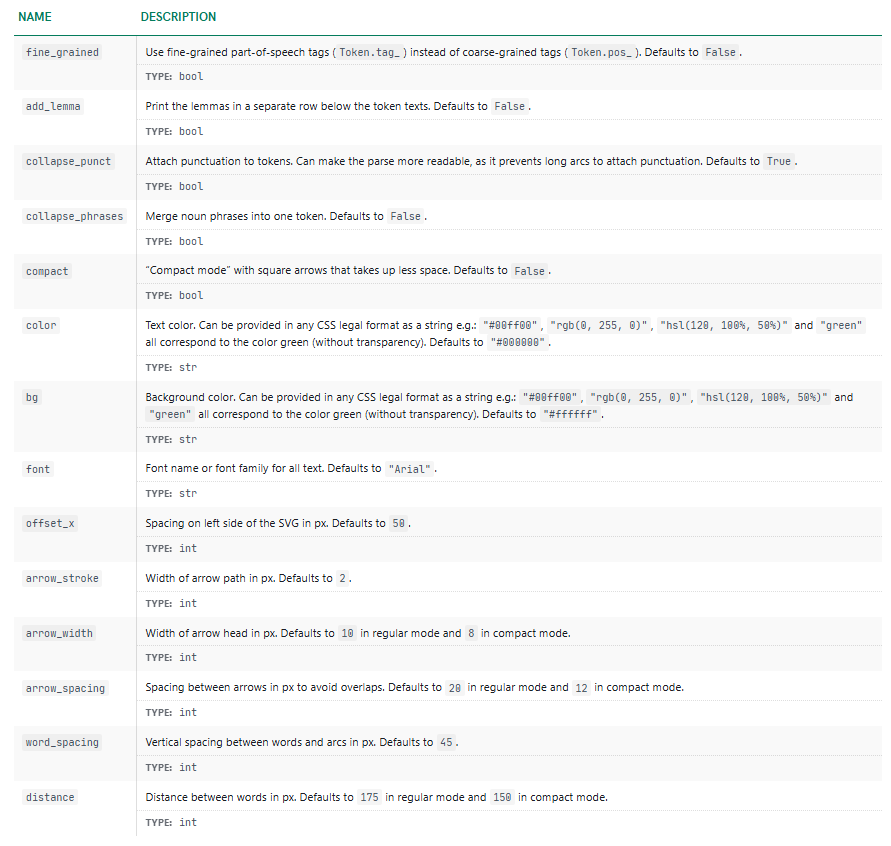

**Задание 1.** Выберите любой небольшой текст (можно отрывок из художественного произведения - из тех, что мы рассматривали, но не берите пока целиком). Загрузите модель для языка, на котором написан этот текст. Сделайте разбор этого текста, выведите табличку зависимостей. Выведите все глагольные вершины предложений. Выведите группы этих вершин.

**Задание 2**. Визуализируйте все предложения выбранного текста. Попробуйте поиграться с настройками визаулизации, не опирайтесь только на то, что было выше.

**Задание 3.** Найдите количество пассивных конструкций в вашем тексте.

**Задание 4**. Найдите долю сложных предложений в вашем тексте (смотрите на тэги acl, advcl, ccomp; посмотрите по таблице, что они значат https://universaldependencies.org/u/dep/).

## Контроль предложений

Можно собрать более полную информацию по тексту. А ещё контролировать уровень предложения, так мы сможем исследовать всё на уровне одного предложения и не ошибиться в обработке разметки.

In [ ]:
text = "Юный чтец любит древние книги. Они находятся в библиотеке."
doc = nlp_ru(text)
rows = []

for sent_idx, sent in enumerate(doc.sents):
    for token_idx, token in enumerate(sent):
        head_text = token.head.text if token.head != token else "ROOT"
        rows.append([
            sent_idx,                # номер предложения
            token_idx,                # локальный номер токена в предложении (сброс на 0)
            token.text,
            token.lemma_,
            token.pos_,
            token.dep_,
            token.head.i,             # глобальный индекс головы (обычно в том же предложении)
            head_text
        ])

df = pd.DataFrame(rows, columns=[
    "id_sentence", "token_id", "token", "lemma", "pos", "deprel", "head_id", "head_token"
])

df

Теперь мы можем "передвигаться" по номерам предложений. Ура!

In [ ]:
sent_one = df[df['id_sentence'] == 0]
sent_one

## Синтаксическая сложность

Ну и последнее на сегодня: простенькая метрика синтаксической сложности: среднее количество зависимых. Сравним "Клеветникам России" Пушкина с переводом на родственный польский язык (перевод Юлиана Эйсмонда).

In [ ]:
text_pushkin_ru = '''
О чем шумите вы, народные витии?
Зачем анафемой грозите вы России?
Что возмутило вас? волнения Литвы?
Оставьте: это спор славян между собою,
Домашний, старый спор, уж взвешенный судьбою,
Вопрос, которого не разрешите вы.

Уже давно между собою
Враждуют эти племена;
Не раз клонилась под грозою
То их, то наша сторона.
Кто устоит в неравном споре:
Кичливый лях, иль верный росс?
Славянские ль ручьи сольются в русском море?
Оно ль иссякнет? вот вопрос.

Оставьте нас: вы не читали
Сии кровавые скрижали;
Вам непонятна, вам чужда
Сия семейная вражда;
Для вас безмолвны Кремль и Прага;
Бессмысленно прельщает вас
Борьбы отчаянной отвага —
И ненавидите вы нас…

За что ж? ответствуйте: за то ли,
Что на развалинах пылающей Москвы
Мы не признали наглой воли
Того, под кем дрожали вы?
За то ль, что в бездну повалили
Мы тяготеющий над царствами кумир
И нашей кровью искупили
Европы вольность, честь и мир?..

Вы грозны на словах — попробуйте на деле!
Иль старый богатырь, покойный на постеле,
Не в силах завинтить свой измаильский штык?
Иль русского царя уже бессильно слово?
Иль нам с Европой спорить ново?
Иль русский от побед отвык?
Иль мало нас? Или от Перми до Тавриды,
От финских хладных скал до пламенной Колхиды,
От потрясенного Кремля
До стен недвижного Китая,
Стальной щетиною сверкая,
Не встанет русская земля?..
Так высылайте ж к нам, витии,
Своих озлобленных сынов:
Есть место им в полях России,
Среди нечуждых им гробов.
'''

text_pushkin_pl = '''
Czemuż ludowi mówcy, czemu
klnie Rosyę wasz namiętny chór?
Co was wzburzyło? Litwy wrzenie?
Zostawcie! To słowiański spór,
domowe, stare powaśnienie,
obce mordowi krwiożerczemu...

Oddawna z sobą te plemiona
zaciekłe boje toczą już...
Nieraz to ich to nasza strona
chyliła się śród groźnych burz.

Kto z nas zwycięży w tym nierównym sporze
czy hardy Lach, czy wierny Ross?
Rzeki słowiańskie wpadną w ruskie morze,
czy ono wyschnie — to rozsądzi los.

Zostawcie nas. Wszak wy nie znacie
tych krwią ociekających stron,
stron wykąpanych w krwi szkarłacie,
gdzie każda głoska — bój i zgon.
Dla was jest obcy, niepojęty
odwieczny nasz rodzinny spór.
Dla was są nieme Kreml i Praga,
obudzą zachwyt wasz odwaga
szalonych walk na śmierć i życie
i konających zapał święty,
więc szczerze nas nienawidzicie...

Zaco? Powiedzcie? Ach zatoli,
że na moskiewskich rozwalinach
nie przyznaliśmy Tego woli
co w waszych szerzył lęk krainach?

Żeśmy Bożyszcze w proch zwalili
pod nasze bohaterskie stopy
i krwią rosyjską okupili
wolność i spokój Europy?

Czy mało nas? Od Permu do Taurydy,
od fińskich chłodnych skał do gór Kolchidy,
od wstrząśniętego Kremla aż po Chiny,
jeżąc stalowe swe szczeciny,
powstanie groźnie ruski lud...
Więc ślijcie przeciw nam na wschód
swe złości pełne, harde syny,...
co chcą nas zwalić do swych stóp...
W głębinie Rosyi są równiny,
kędy oszczercy znajdą grób.
'''

In [ ]:
doc_pushkin_ru = nlp_ru(text_pushkin_ru)
doc_pushkin_pl = nlp_pol(text_pushkin_pl)

Осталось извлечь все группы вершин и зависимых:

In [ ]:
total_deps_ru = sum(len(list(token.children)) for token in doc_pushkin_ru)
print([list(token.children) for token in doc_pushkin_ru])
print(total_deps_ru)

In [ ]:
total_deps_pl = sum(len(list(token.children)) for token in doc_pushkin_pl)
print([list(token.children) for token in doc_pushkin_pl])
print(total_deps_pl)

Теперь высчитаем среднее значение:

In [ ]:
avg_deps_ru = total_deps_ru / len(doc_pushkin_ru) if len(doc) > 0 else 0
avg_deps_pl = total_deps_pl / len(doc_pushkin_pl) if len(doc) > 0 else 0
print(avg_deps_ru)
print(avg_deps_pl)

А теперь сравним с английским переводом Томаса Шоу:

In [ ]:
nlp_en = spacy.load("en_core_web_sm")

In [ ]:
text_pushkin_en = '''
Why rave ye, babblers, so — ye lords of popular wonder?
Why such anathemas 'gainst Russia do you thunder?
What moves your idle rage? Is 't Poland's fallen pride?
'T is but Slavonic kin among themselves contending,
An ancient household strife, oft judged but still unending,
A question which, be sure, ye never can decide.
For ages past still have contended
These races, though so near allied:
And oft 'neath Victory's storm has bended
Now Poland's, and now Russia's side.
Which shall stand fast in such commotion,
The haughty Pole, or faithful Russ?
And shall Slavonic streams meet in a Russian ocean —
Or that dry up? This is point for us.

Peace, peace! your eyes are all unable
To read our history's bloody table;
Strange in your sight and dark must be
Our springs of household enmity!
To you the Kreml and Praga's tower
Are voiceless all, — you mark the fate
And daring of the battle-hour, —
And understand us not, but hate — —

What stirs ye? Is it that this nation
On Moscow's flaming wall, blood-slaked and ruin-quenched,
Spurned back the insolent dictation
Of Him before whose nod ye blenched?
Is it that into dust we shattered
The Dagon that weighed down the earth so wearily?
And our best blood so freely scattered
To buy for Europe peace and liberty?

Ye 're bold of tongue — but hard, would ye in deed but try it.
Or is the hero, now reclined in laurelled quiet,
Too weak to fix once more Izmail's red bayonet?
Or hath the Russian Tsar ever in vain commanded?
Or must we meet all Europe banded?
Have we forgot to conquer yet?
Or rather, shall they not, from Perm to Tauris' fountains,
From the hot Colchian steppes to Finland's icy mountains,
From the grey Kreml's half-shattered wall,
To far Kathay, in dotage buried, —
A steely rampart close and serried,
Rise, Russia's warriors, one and all?
Then send your numbers without number,
Your maddened sons, your goaded slaves,
In Russia's plains there 's room to slumber,
And well they 'll know their brethren's graves!
'''
doc_pushkin_en = nlp_en(text_pushkin_en)
total_deps_en = sum(len(list(token.children)) for token in doc_pushkin_en)
avg_deps_en = total_deps_en / len(doc_pushkin_en) if len(doc) > 0 else 0
print(avg_deps_en)

В английском зависимых больше - конечно, не настолько, чтобы делать серьёзные выводы, однако любопытно.

**Задание 5**. Сравните среднее количество зависимых на токен текста. Возьмите библейские тексты (Моисеево Пятикнижие) и Новый Завет. Есть ли отличия? 

In [ ]:
url = 'https://raw.githubusercontent.com/aleksklimow/DH_programming_24-25/refs/heads/main/seminars/New_testament.txt'
response = requests.get(url)
text_nt = response.text

url = 'https://raw.githubusercontent.com/aleksklimow/DH_programming_24-25/refs/heads/main/seminars/Torah.txt'
response = requests.get(url)
text_torah = response.text